In [15]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import load_data, img_path
from cns.utils.cutoff import count_below_lim, find_knee
file_type = ".pdf"

In [17]:
plt.rcParams.update({'font.size': 14, 'figure.dpi': 100, 'figure.figsize': (5, 5)})

In [18]:
data = load_data()
datasets = list(data.keys())

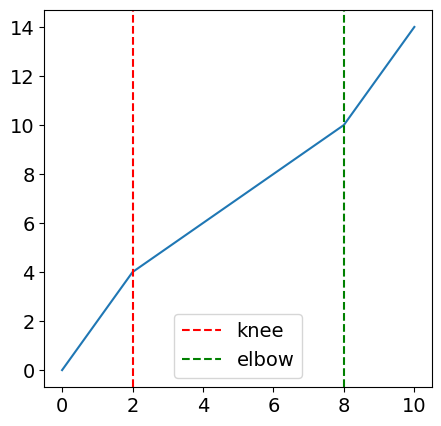

In [19]:
test_vals = [0, 2, 4, 5, 6, 7, 8, 9, 10, 12, 14]
knee, _ = find_knee(test_vals, delta_x=1, convex=True, allow_pad=False)
elbow, _ = find_knee(test_vals, delta_x=1, convex=False, allow_pad=False)
plt.plot(test_vals)
plt.axvline(x=knee, color='r', linestyle='--', label='knee')
plt.axvline(x=elbow, color='g', linestyle='--', label='elbow')
plt.legend()


In [45]:
ane_count = {}
ane_cutoffs = {}
ane_deltas = {}
feature = "ane_total_cn_frac_aut"
max_val = 0.01
for k, v in data.items():
    ane_cutoffs[k], ane_count[k], ane_deltas[k] = count_below_lim(v.samples[feature], max_val=max_val, steps=100)

101 0.01 0.13174946004319654
PCAWG 16 35.422565006156134
101 0.01 0.11542359140656668
TCGA_hg19 10 52.501999265861215
101 0.01 0.0012345679012345679
TRACERx 11 0.04366389911698259


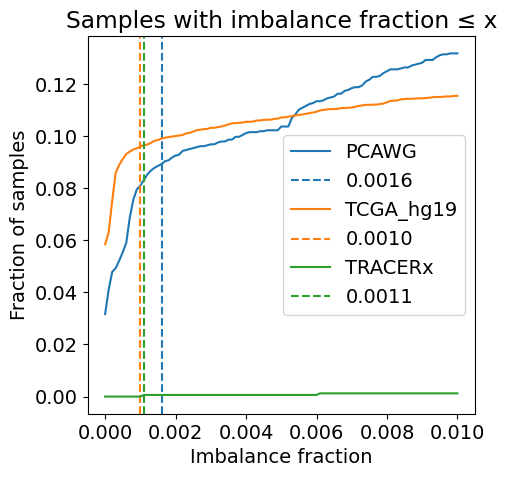

In [48]:
for k, v in ane_count.items():
    plt.plot(ane_cutoffs[k], v, label=k, color=data[k].color)    
    if  np.max(v) <= 0:
        continue
    print(len(v), np.max(ane_cutoffs[k]), np.max(v))
    knee_index, knee_value = find_knee(v, ane_deltas[k], convex=True, dist=10)
    print(k, knee_index, knee_value)
    x_pos = ane_cutoffs[k][knee_index]
    plt.axvline(x_pos, color=data[k].color, linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with imbalance fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_imbalance_fraction{file_type}", bbox_inches="tight")

In [26]:
cov_count = {}
cov_cutoffs = {}
cov_deltas = {}
feature = "cover_frac_aut"
min_val = 0.75
for k, v in data.items():
    cov_cutoffs[k], cov_count[k], cov_deltas[k] = count_below_lim(v.samples[feature], min_val=min_val, steps=250)

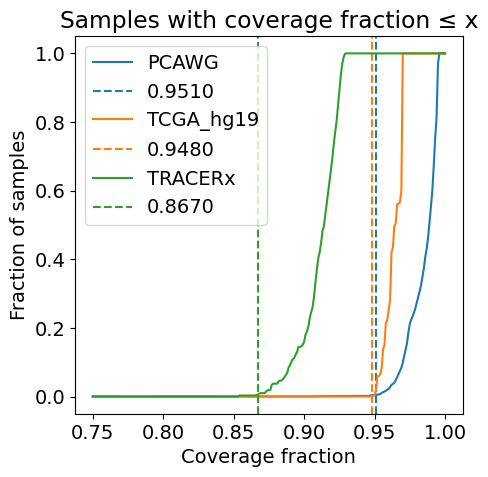

In [27]:
for k, v in cov_count.items():
    plt.plot(cov_cutoffs[k], v, label=k, color=data[k].color)        
    knee_index, knee_value = find_knee(v, cov_deltas[k], convex=False, dist=10)
    x_pos = cov_cutoffs[k][knee_index]
    plt.axvline(x_pos, color=data[k].color, linestyle="--", label=f"{x_pos:.4f}")

plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
plt.savefig(f"{img_path}/fig_samples_coverage_fraction{file_type}", bbox_inches="tight")

In [24]:
break_count = {}
break_cutoffs = {}
break_deltas = {}
feature = "breaks_aut"
steps = 250
for k, v in data.items():
    break_cutoffs[k], break_count[k], break_deltas[k] = count_below_lim(v.samples[feature], max_val=steps, steps=steps)

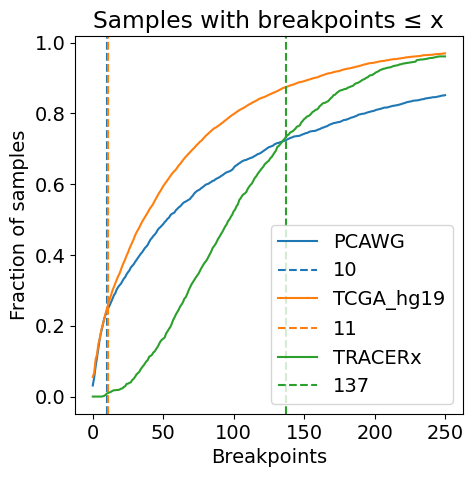

In [25]:
for k, v in break_count.items():
    plt.plot(break_cutoffs[k], v, label=k, color=data[k].color)        
    knee_index, knee_value = find_knee(v, break_deltas[k], convex=True, dist=10)
    x_pos = break_cutoffs[k][knee_index]
    plt.axvline(x_pos, color=data[k].color, linestyle="--", label=f"{int(x_pos)}")

plt.ylabel("Fraction of samples")
plt.xlabel("Breakpoints")
plt.title(f"Samples with breakpoints ≤ x")
plt.legend()
plt.savefig(f"{img_path}/fig_samples_breaks_fraction{file_type}", bbox_inches="tight")